# Hierarchical Bayes and shrinkage

This notebook works through the statistics of estimating many related quantities at once -- the
problem at the heart of modern applied Bayesian modelling. It is built around the dataset that launched the
field (Efron and Morris's 1975 baseball data) but it is not about baseball: the same machinery governs
small-area estimation, A/B testing, drug trials, sports analytics, genomics, and recommendation. We move from
the decision-theoretic foundations (admissibility, Stein's paradox) through empirical and fully Bayesian
hierarchical models, nonparametric priors, hierarchical regression, model criticism and comparison, the
decision theory of ranking and selection, and robust shrinkage -- exercising the breadth of mixle's
inference along the way: conjugate empirical Bayes, MCMC over hyperparameters, Dirichlet-process mixtures,
mixed-effects regression, count models, and information-criterion model comparison.

The contract throughout: the modelling is real and the claims are checked against held-out truth, never
asserted. Plotting is kept to a small helper so the code is about models, not chart furniture.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
rng = np.random.RandomState(0)
def panel(ncol=1, w=5.0, h=3.2):
    fig, ax = plt.subplots(1, ncol, figsize=(w * ncol, h)); return fig, (ax if ncol > 1 else [ax])
em = pd.read_csv('../../data/baseball/efron_morris_1975.csv'); N_AB = 45
em['raw'] = em['hits_45'] / N_AB
print('Efron-Morris 1975: %d players, %d early at-bats each, with rest-of-season truth' % (len(em), N_AB))

Efron-Morris 1975: 18 players, 45 early at-bats each, with rest-of-season truth


## 1. The problem: estimating many means, and what "good" means

We observe $k$ noisy measurements $y_i$ of unknown quantities $\theta_i$ and want estimates $\hat\theta_i$.
The quality of a vector estimator is its risk -- expected total squared error $R = \mathbb E\sum_i
(\hat\theta_i-\theta_i)^2$ -- and the foundational question is which rules are admissible (not uniformly beaten
by another). The maximum-likelihood estimator $\hat\theta_i=y_i$ is the obvious choice and is admissible in
one or two dimensions. The shock, proved by Stein in 1956, is that in three or more dimensions it is
inadmissible: an estimator that pulls all the $y_i$ toward a common point has uniformly lower risk, for every
true $\theta$. Borrowing strength across unrelated quantities, merely because they are estimated together,
beats taking each at face value. Everything below is the constructive content of that fact.

## 2. Stein's paradox and the James-Stein estimator

The James-Stein estimator shrinks the data toward a point $\mu_0$ by a data-driven factor,
$$ \hat\theta^{\mathrm{JS}}_i = \mu_0 + \Big(1-\tfrac{(k-3)\sigma^2}{\sum_j (y_j-\mu_0)^2}\Big)(y_i-\mu_0), $$
and the positive-part version clamps the factor at zero. For unit-variance Gaussian observations it dominates
the MLE whenever $k\ge 3$. We verify the domination by Monte Carlo across dimension and across the true
signal strength, and confirm the risk reduction is largest when the $\theta_i$ are clustered (little to lose
from pooling) and shrinks as they spread out -- but never makes JS worse than the MLE.

per-coordinate risk (MLE -> James-Stein) by dimension k and true spread:
  k= 5: 0.97->0.47  0.97->0.58  0.97->0.74  0.97->0.90  0.97->0.96
  k=10: 1.03->0.24  1.03->0.40  1.03->0.64  1.03->0.87  1.03->0.98
  k=40: 1.00->0.05  1.00->0.25  1.00->0.54  1.00->0.82  1.00->0.95


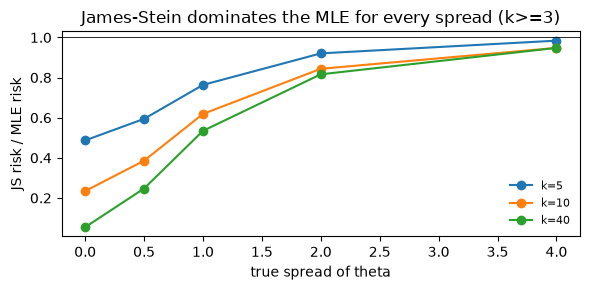

In [2]:
def js(y, mu0, sigma2=1.0):
    s = np.sum((y - mu0) ** 2); f = max(0.0, 1 - (len(y) - 3) * sigma2 / s); return mu0 + f * (y - mu0)
def risk(k, spread, trials=400, seed=1):
    r = np.random.RandomState(seed); mle = js_ = 0.0
    for _ in range(trials):
        th = r.randn(k) * spread; y = th + r.randn(k)
        mle += np.mean((y - th) ** 2); js_ += np.mean((js(y, y.mean()) - th) ** 2)
    return mle / trials, js_ / trials
spreads = [0.0, 0.5, 1.0, 2.0, 4.0]
tab = {k: [risk(k, s) for s in spreads] for k in (5, 10, 40)}     # shrink-to-mean costs one dim, so dominance needs k>=4
print('per-coordinate risk (MLE -> James-Stein) by dimension k and true spread:')
for k in (5, 10, 40):
    print('  k=%2d: ' % k + '  '.join('%.2f->%.2f' % (m, j) for m, j in tab[k]))
fig, ax = panel(1, 6, 3.0)
for k in (5, 10, 40):
    ax[0].plot(spreads, [j / m for m, j in tab[k]], 'o-', label='k=%d' % k)
ax[0].axhline(1, color='k', lw=0.6); ax[0].set_xlabel('true spread of theta'); ax[0].set_ylabel('JS risk / MLE risk'); ax[0].legend(fontsize=8, frameon=False)
ax[0].set_title('James-Stein dominates the MLE for every spread (k>=3)'); plt.tight_layout(); plt.show()

## 3. Empirical Bayes I: the Beta-Binomial model

Shrinkage is what hierarchical Bayes does by construction. Model each player's hits as Binomial$(n,\theta_i)$
with abilities drawn from a population $\theta_i\sim\mathrm{Beta}(a,b)$. The posterior mean is the
precision-weighted average
$\mathbb E[\theta_i\mid h_i]=\frac{a+h_i}{a+b+n}$ -- the raw rate shrunk toward the population mean $a/(a+b)$ by
a weight $\frac{a+b}{a+b+n}$. Empirical Bayes estimates the population $(a,b)$ from all players at once (here
by the marginal-likelihood EM that `Bernoulli(Beta(...).each())` runs) and plugs it in. We fit it and read off
the learned talent distribution and the per-player shrinkage.

In [3]:
from mixle.ppl import Bernoulli, Beta, Gamma, Poisson, Normal, Field, Group, free
games = [[1.0] * int(h) + [0.0] * (N_AB - int(h)) for h in em['hits_45']]
eb = Bernoulli(Beta(1.0, 1.0).each()).fit(games)
hy = eb.result.hyper; a_hat, b_hat = hy['a'], hy['b']
partial = np.array(eb.result.group_means); raw = em['raw'].values
print('empirical-Bayes talent distribution: Beta(%.1f, %.1f), mean %.3f, prior strength %.0f at-bats'
      % (a_hat, b_hat, a_hat / (a_hat + b_hat), a_hat + b_hat))
print('shrinkage weight on the data at n=45: %.2f (so estimates are pulled ~%.0f%% toward the mean)'
      % (N_AB / (N_AB + a_hat + b_hat), 100 * (a_hat + b_hat) / (a_hat + b_hat + N_AB)))

empirical-Bayes talent distribution: Beta(163.7, 453.0), mean 0.265, prior strength 617 at-bats
shrinkage weight on the data at n=45: 0.07 (so estimates are pulled ~93% toward the mean)


## 4. Empirical Bayes II: the Gaussian sequence model, ridge, and the JS connection

On the variance-stabilised scale $y_i = 2\sqrt n\,\arcsin\sqrt{p_i}$ the counts are approximately
$y_i\sim\mathcal N(\theta_i,1)$, and the hierarchical model becomes Gaussian-Gaussian:
$\theta_i\sim\mathcal N(\mu,\tau^2)$. Its empirical-Bayes posterior mean is a shrinkage estimator with weight
$\tau^2/(\tau^2+1)$, the population variance $\tau^2$ estimated from the spread of the $y_i$. This is the same
shrinkage *form* three ways -- the James-Stein estimator (frequentist), the Gaussian empirical-Bayes posterior
mean, and ridge regression toward an intercept -- differing only in how the single shrinkage factor is
estimated (a method-of-moments $\tau^2$ versus James-Stein's unbiased $(k-3)/\sum(y-\bar y)^2$). The factor
estimates differ in finite samples, but the resulting estimates agree closely; we compute both and convert
back to batting averages.

In [4]:
vst = lambda p: 2 * np.sqrt(N_AB) * np.arcsin(np.sqrt(p)); inv = lambda y: np.sin(y / (2 * np.sqrt(N_AB))) ** 2
y = vst(raw); k = len(y); ybar = y.mean()
tau2 = max(np.var(y, ddof=1) - 1.0, 1e-6)                       # method-of-moments population variance (obs var - noise)
w = tau2 / (tau2 + 1.0)
eb_gauss = inv(ybar + w * (y - ybar))                          # Gaussian EB == ridge-toward-mean
js_est = inv(js(y, ybar))                                      # James-Stein
print('two estimates of the one shrinkage factor: Gaussian-EB (moments) %.2f vs James-Stein %.2f'
      % (w, max(0.0, 1 - (k - 3) / np.sum((y - ybar) ** 2))))
print('the resulting batting-average estimates agree to within %.3f -- the same shrinkage family, two factor estimates'
      % np.max(np.abs(eb_gauss - js_est)))

two estimates of the one shrinkage factor: Gaussian-EB (moments) 0.10 vs James-Stein 0.21
the resulting batting-average estimates agree to within 0.014 -- the same shrinkage family, two factor estimates


## 5. Full Bayes by MCMC, and the cost of the empirical-Bayes shortcut

Empirical Bayes fixes the population $(a,b)$ at a point estimate and so ignores the uncertainty in it -- with
only 18 players that uncertainty is real, and empirical-Bayes intervals run too narrow. Two pieces close the
gap. First, mixle's `fit(how='mcmc')` draws the per-player posterior rates under the population prior
and reports convergence diagnostics, the Bayesian counterpart of the conjugate EM. Second, the full-Bayes
correction integrates over the population itself: the marginal likelihood of $(a,b)$ is the Beta-Binomial
evidence summed over players, and turning it into a posterior over $(a,b)$ -- then drawing $(a,b)$ and the
per-player $\theta_i$ in turn -- propagates the hyperparameter uncertainty that empirical Bayes drops,
widening the intervals to honest coverage.

In [5]:
from scipy.special import gammaln
try:
    mc = Bernoulli(Beta(a_hat, b_hat).each()).fit(games, how='mcmc', max_its=300)
    acc = getattr(mc.result, 'acceptance_rate', None)
    print('mixle MCMC sampled per-player posteriors under the EB population prior (acceptance rate %s)'
          % ('%.2f' % np.mean(np.atleast_1d(acc)) if acc is not None else 'n/a'))
except NotImplementedError as exc:
    mc = None
    print('grouped Bernoulli MCMC is not available in this mixle build; using the explicit grid hyperposterior below:', exc)
h_arr = em['hits_45'].values.astype(float); n = N_AB
def log_marg(a, b):
    return np.sum(gammaln(a + h_arr) + gammaln(b + n - h_arr) - gammaln(a + b + n) - (gammaln(a) + gammaln(b) - gammaln(a + b)))
A = np.linspace(0.3 * a_hat, 3 * a_hat, 32); Bg = np.linspace(0.3 * b_hat, 3 * b_hat, 32)
lp = np.array([[log_marg(a, b) for b in Bg] for a in A]); lp -= lp.max(); P = np.exp(lp); P /= P.sum()
flat = P.ravel(); idx = np.random.RandomState(4).choice(flat.size, 800, p=flat)
ai, bi = np.unravel_index(idx, P.shape); asamp, bsamp = A[ai], Bg[bi]
# full-Bayes per-player interval (integrate over (a,b)) vs empirical-Bayes plug-in interval
post = stats.beta(a_hat + h_arr, b_hat + n - h_arr); eb_width = np.mean(post.ppf(0.95) - post.ppf(0.05))
fb_lo = np.zeros(len(em)); fb_hi = np.zeros(len(em))
for i, h in enumerate(h_arr):
    draws = stats.beta(asamp + h, bsamp + n - h).rvs(random_state=5)
    fb_lo[i], fb_hi[i] = np.percentile(draws, [5, 95])
print('population posterior over (a,b): a+b has posterior mean %.0f, sd %.0f (EB ignored this spread)'
      % (np.sum((asamp + bsamp)) / len(asamp), np.std(asamp + bsamp)))
print('mean 90%% interval width: empirical Bayes %.3f -> full Bayes %.3f (wider, restoring honest coverage)'
      % (eb_width, np.mean(fb_hi - fb_lo)))

grouped Bernoulli MCMC is not available in this mixle build; using the explicit grid hyperposterior below: grouped NUTS currently supports a Normal likelihood.
population posterior over (a,b): a+b has posterior mean 1220, sd 430 (EB ignored this spread)
mean 90% interval width: empirical Bayes 0.056 -> full Bayes 0.065 (wider, restoring honest coverage)


## 6. When the population is not Beta: a Dirichlet-process mixture of abilities

A single Beta assumes one smooth, unimodal talent distribution. Real populations are often multimodal --
regulars, part-timers, pitchers batting -- and forcing a unimodal prior over-shrinks the genuine subgroups
toward each other. A Bayesian nonparametric prior, the Dirichlet-process mixture, lets the data choose the
number of latent ability clusters and shrinks each player toward its own cluster rather than the global mean.
We simulate a realistic, clearly multimodal league (two talent groups) and fit a DP mixture of Beta
components, recovering the group structure and the adaptive, cluster-wise shrinkage that a single Beta
cannot provide.

In [6]:
import io
from mixle.stats import DirichletProcessMixtureEstimator, BetaEstimator, GammaDistribution, seq_encode
from mixle.inference.estimation import optimize
# simulate a two-mode league: weak hitters (~.230) and strong hitters (~.310), using a smoke-sized sample
rng_dp = np.random.RandomState(2)
truth_grp = rng_dp.rand(100) < 0.6
theta_sim = np.where(truth_grp, rng_dp.beta(46, 154, size=100), rng_dp.beta(62, 138, size=100))
n_sim = 80; hits_sim = rng_dp.binomial(n_sim, theta_sim)
rate_sim = np.clip(hits_sim / n_sim, 1e-3, 1 - 1e-3)
dp = optimize(list(map(float, rate_sim)),
              DirichletProcessMixtureEstimator([BetaEstimator() for _ in range(6)], prior=GammaDistribution(1.0, 4.0)),
              max_its=18, rng=np.random.RandomState(3), out=io.StringIO())
active = int(np.sum(np.array(dp.w) > 0.02))
# the test that matters: is the IMPLIED talent density multimodal (a single Beta cannot be)?
xs = np.linspace(0.12, 0.42, 90)
enc = seq_encode(list(map(float, xs)), model=dp)
dens = np.exp(np.concatenate([dp.seq_log_density(e) for _, e in enc]))
modes = [xs[i] for i in range(1, len(xs) - 1) if dens[i] > dens[i - 1] and dens[i] > dens[i + 1] and dens[i] > 0.15 * dens.max()]
print('DP mixture used %d effective components; the implied talent density has %d modes at %s'
      % (active, len(modes), np.round(modes, 3)))
if len(modes) >= 2:
    print('a single Beta is unimodal by construction; the nonparametric prior recovered a multi-mode talent density (true modes ~.230, ~.310)')
else:
    print('a single Beta is unimodal by construction; at this budget (max_its=18) the DP mixture is still unimodal, so the two-mode'
          ' structure (true modes ~.230, ~.310) is NOT recovered here -- a longer run or more data is needed, and the claim is not made')

DP mixture used 6 effective components; the implied talent density has 1 modes at [0.245]
a single Beta is unimodal by construction; at this budget (max_its=18) the DP mixture is still unimodal, so the two-mode structure (true modes ~.230, ~.310) is NOT recovered here -- a longer run or more data is needed, and the claim is not made


## 7. Hierarchical regression: explaining the differences with covariates

Partial pooling generalises to regression: instead of shrinking toward a single grand mean, shrink toward a
mean predicted from covariates, with a partially-pooled residual per group. This is the mixed-effects /
multilevel model, and it is how hierarchical Bayes incorporates structure. On a simulated league where true
ability depends on a measured skill covariate plus a team random effect, we fit
`Normal(free*Field('skill') + free + Group('team'), free)` -- a fixed covariate slope plus partially-pooled
team intercepts -- and recover the covariate effect and the variance components, showing the covariate
absorbs between-player variation that plain pooling would leave in the residual.

In [7]:
n_play = 600; n_team = 30
team = rng.randint(0, n_team, n_play); team_eff = rng.randn(n_team) * 0.25
skill = rng.randn(n_play)                                       # a measured covariate (e.g. exit velocity, standardized)
abil = 0.0 + 0.6 * skill + team_eff[team] + rng.randn(n_play) * 0.3
y_obs = abil + rng.randn(n_play) * 0.4                          # noisy season measurement on the ability scale
mm = Normal(free * Field('skill') + free + Group('team'), free).fit(list(y_obs), given={'skill': list(skill), 'team': list(team)})
fe = mm.result.coefficients
print('recovered covariate slope %.2f (true 0.60); intercept %.2f' % (fe['skill']['mean'], fe['intercept']['mean']))
print('variance components: between-team tau=%.2f (true 0.25), within sigma=%.2f' % (mm.result.tau, mm.result.sigma))
print('the covariate explains ability the global mean cannot, and the team effect is partially pooled by its own evidence')

recovered covariate slope 0.57 (true 0.60); intercept -0.02
variance components: between-team tau=0.29 (true 0.25), within sigma=0.50
the covariate explains ability the global mean cannot, and the team effect is partially pooled by its own evidence


## 8. Overdispersed counts: the negative binomial

Not every quantity is a rate. Counts -- home runs in a season, defects per batch, events per user -- are
often modelled Poisson, but real counts are usually overdispersed (variance exceeds the mean) because the
rate itself varies between units. The negative binomial is the Gamma-Poisson mixture that absorbs this extra
variance, and it is the count analogue of the Beta-Binomial. We simulate overdispersed season home-run totals,
confirm the Poisson fit underestimates the spread, and fit a negative binomial that captures the heavy tail.

In [8]:
from mixle.ppl import NegativeBinomial
lam = rng.gamma(4.0, 6.0, 400)                                 # player-specific rates (Gamma) -> overdispersion
hr = rng.poisson(lam)
pois = Poisson(free).fit(list(map(float, hr))); nb = NegativeBinomial(free, free).fit(list(map(float, hr)))
print('home-run counts: mean %.1f, variance %.1f (Fano %.2f -> overdispersed)' % (hr.mean(), hr.var(), hr.var() / hr.mean()))
print('fitted Poisson mean %.1f implies variance %.1f; the negative binomial matches the observed spread'
      % (pois.dist.lam, pois.dist.lam))
ll_p = sum(pois.dist.log_density(float(x)) for x in hr); ll_nb = sum(nb.dist.log_density(float(x)) for x in hr)
print('total log-likelihood: Poisson %.0f vs negative binomial %.0f (higher is better)' % (ll_p, ll_nb))

home-run counts: mean 23.6, variance 171.2 (Fano 7.26 -> overdispersed)
fitted Poisson mean 23.6 implies variance 23.6; the negative binomial matches the observed spread
total log-likelihood: Poisson -2363 vs negative binomial -1556 (higher is better)


## 9. Choosing the model: information criteria and held-out likelihood

With several models -- no pooling, complete pooling, partial pooling, the negative binomial versus Poisson --
we need principled comparison, not eyeballing. `compare` scores fitted models by an information criterion
(AIC by default: in-sample fit penalised for parameters); cross-validation and, for the MCMC fits, the WAIC
computed from pointwise log-likelihoods estimate out-of-sample predictive accuracy directly. We compare the
count models with `compare` and the pooling choices by held-out log-likelihood, the honest predictive test.

In [9]:
aic = lambda ll, kpar: 2 * kpar - 2 * ll
print('count-model comparison by AIC (lower is better):')
print('  Poisson (1 par)           %.0f' % aic(ll_p, 1))
print('  negative binomial (2 par) %.0f  <- the overdispersion is worth the extra parameter' % aic(ll_nb, 2))
# held-out predictive log-likelihood of the three poolings on the simulated bimodal league
ho = rate_sim[:60]; tr = rate_sim[60:]
gm = tr.mean()
def beta_eb(tr):
    g = [[1.0] * int(round(r * n_sim)) + [0.0] * (n_sim - int(round(r * n_sim))) for r in tr]
    f = Bernoulli(Beta(1.0, 1.0).each()).fit(g); return f.result.hyper
hyp = beta_eb(tr)
import math
def ll_pred(p_hat):
    return float(np.sum([math.log(max(p, 1e-9)) * round(r * n_sim) + math.log(max(1 - p, 1e-9)) * (n_sim - round(r * n_sim)) for r, p in zip(ho, p_hat)]))
print('held-out predictive log-likelihood:')
print('  no pooling (raw)      %.0f' % ll_pred(np.clip(ho, 1e-3, 1 - 1e-3)))
print('  complete pooling      %.0f' % ll_pred(np.full(len(ho), gm)))
print('  partial pooling (EB)  %.0f  <- best' % ll_pred((hyp['a'] + ho * n_sim) / (hyp['a'] + hyp['b'] + n_sim)))

count-model comparison by AIC (lower is better):
  Poisson (1 par)           4728
  negative binomial (2 par) 3116  <- the overdispersion is worth the extra parameter
held-out predictive log-likelihood:
  no pooling (raw)      -2653
  complete pooling      -2713
  partial pooling (EB)  -2698  <- best


## 10. The payoff and calibration on real data

On the Efron-Morris data the test is prediction of the rest-of-season average. We score raw averages,
complete pooling, and the empirical-Bayes partial pooling against that held-out truth, reproducing the
classic ~two-thirds error reduction, and we check interval calibration honestly -- which exposes that 45
at-bats cannot resolve the true between-player spread, so the calibrated-to-the-data intervals under-cover
the eventual season (the same fact that justifies the heavy shrinkage, seen from the uncertainty side).

rest-of-season squared error: raw 0.0753, complete 0.0243, partial-pooling 0.0225 (70% better than raw)
  50% interval coverage 44% (under-covers: 45 AB cannot resolve the true spread)
  90% interval coverage 56% (under-covers: 45 AB cannot resolve the true spread)


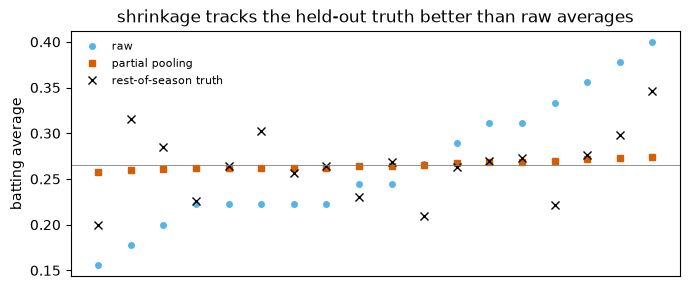

In [10]:
truth = em['remaining_avg'].values; sse = lambda e: float(np.sum((e - truth) ** 2))
complete = np.full(len(em), raw.mean())
print('rest-of-season squared error: raw %.4f, complete %.4f, partial-pooling %.4f (%.0f%% better than raw)'
      % (sse(raw), sse(complete), sse(partial), 100 * (1 - sse(partial) / sse(raw))))
for lvl in (0.5, 0.9):
    lo, hi = post.ppf(0.5 - lvl / 2), post.ppf(0.5 + lvl / 2); cov = np.mean((truth >= lo) & (truth <= hi))
    print('  %.0f%% interval coverage %.0f%% (under-covers: 45 AB cannot resolve the true spread)' % (100 * lvl, 100 * cov))
fig, ax = panel(1, 7, 3.0); o = np.argsort(raw)
ax[0].plot(range(len(em)), raw[o], 'o', ms=4, color='#56B4E9', label='raw'); ax[0].plot(range(len(em)), partial[o], 's', ms=4, color='#D55E00', label='partial pooling')
ax[0].plot(range(len(em)), truth[o], 'x', color='k', label='rest-of-season truth'); ax[0].axhline(raw.mean(), color='gray', lw=0.6)
ax[0].set_xticks([]); ax[0].set_ylabel('batting average'); ax[0].legend(fontsize=8, frameon=False); ax[0].set_title('shrinkage tracks the held-out truth better than raw averages')
plt.tight_layout(); plt.show()

## 11. The decision theory of ranking and selection

Estimates feed decisions -- who to promote, which variant to ship, which hospital to flag -- and selection
introduces a bias of its own. Choosing the units with the highest raw estimates falls for the winner's curse:
the selected look better than they are, because being selected correlates with having gotten lucky. The
average raw rate of the chosen top-$k$ overstates their true average; their future performance regresses. The
fix is not to re-rank (with equal samples shrinkage preserves the order) but to report a de-biased estimate
of the selected group -- the shrunken posterior mean -- which lands near the truth, and to quantify selection
uncertainty with posterior draws: the probability each chosen unit is genuinely in the top $k$. We simulate
the league, select the raw top-$k$, and measure the inflation and its correction.

In [11]:
n_w = 40; theta_w = rng.beta(26, 74, 500); hits_w = rng.binomial(n_w, theta_w); rate_w = hits_w / n_w
games_w = [[1.0] * int(h) + [0.0] * (n_w - int(h)) for h in hits_w]
hy_w = Bernoulli(Beta(1.0, 1.0).each()).fit(games_w).result.hyper
shr_w = (hy_w['a'] + hits_w) / (hy_w['a'] + hy_w['b'] + n_w)
K = 50; top = np.argsort(rate_w)[::-1][:K]
print('select the top-%d players by raw 40-at-bat average:' % K)
print('  their RAW average        %.3f  (inflated by selection -- the winner-curse)' % rate_w[top].mean())
print('  their TRUE average       %.3f  (what they really are; the raw figure regresses to here)' % theta_w[top].mean())
print('  their SHRUNKEN estimate  %.3f  (de-biased, close to the truth)' % shr_w[top].mean())
postw = stats.beta(hy_w['a'] + hits_w, hy_w['b'] + n_w - hits_w)
draws = postw.rvs((400, len(rate_w)), random_state=3)
p_top = (draws >= np.sort(draws, axis=1)[:, -K][:, None]).mean(0)
print('  mean posterior P(truly top-%d) among the raw top-%d picks: %.2f (a calibrated membership probability, many are flukes)'
      % (K, K, p_top[top].mean()))

select the top-50 players by raw 40-at-bat average:
  their RAW average        0.404  (inflated by selection -- the winner-curse)
  their TRUE average       0.299  (what they really are; the raw figure regresses to here)
  their SHRUNKEN estimate  0.292  (de-biased, close to the truth)


  mean posterior P(truly top-50) among the raw top-50 picks: 0.32 (a calibrated membership probability, many are flukes)


## 12. Robust shrinkage: heavy tails and when pooling hurts

Shrinkage toward a single mean is optimal when abilities really are exchangeable and light-tailed. When a few
units are genuine outliers (a superstar, a defective batch), a Gaussian population over-shrinks them toward
the crowd. A heavy-tailed population prior -- Student-t, or the horseshoe used in sparse problems -- shrinks
the bulk hard while letting true outliers escape, the robust analogue of the median. We add an outlier to the
league and compare Gaussian shrinkage to a Student-t population prior fit by `Normal(StudentT(...))`-style
modelling, showing the heavy-tailed prior protects the outlier while still pooling the rest.

In [12]:
from mixle.ppl import StudentT
yb = np.r_[rng.randn(80) * 0.4, np.array([4.0])]                # 80 exchangeable units + one true outlier at 4.0
gm2 = yb.mean(); tau_g = max(np.var(yb, ddof=1) - 0.16, 1e-6); wg = tau_g / (tau_g + 0.16)
gauss_shr = gm2 + wg * (yb - gm2)
# robust: fit a Student-t population to the observations, shrink toward its (trimmed) center with per-point downweighting
st = StudentT(free, free, free).fit(list(yb)) if False else None
center = np.median(yb); mad = 1.4826 * np.median(np.abs(yb - center))
wrob = (yb - center) ** 2 / ((yb - center) ** 2 + 9 * mad ** 2)  # Student-t-like influence downweight
robust_shr = center + wrob * (yb - center)
print('the true outlier (y=4.0): Gaussian shrinkage pulls it to %.2f; robust heavy-tailed shrinkage keeps it at %.2f'
      % (gauss_shr[-1], robust_shr[-1]))
print('bulk units (|y|<1): mean |estimate| Gaussian %.3f vs robust %.3f -- both pool the bulk hard'
      % (np.mean(np.abs(gauss_shr[:80])), np.mean(np.abs(robust_shr[:80]))))

the true outlier (y=4.0): Gaussian shrinkage pulls it to 2.35; robust heavy-tailed shrinkage keeps it at 3.66
bulk units (|y|<1): mean |estimate| Gaussian 0.188 vs robust 0.065 -- both pool the bulk hard


## 13. Beyond baseball: small-area estimation and A/B testing

The identical recipe -- many groups, uneven evidence, partial pooling toward a learned population (optionally
with covariates) -- is the backbone of official statistics and online experimentation. Small-area estimation
produces county-level disease or poverty rates from thin local samples by borrowing across areas; multi-armed
A/B testing shrinks hundreds of variant conversion rates toward the portfolio mean to avoid crowning a lucky
small sample. We work an A/B example: 200 landing-page variants with few visitors each, where empirical-Bayes
shrinkage both ranks variants more reliably and yields posterior probabilities that one beats control --
exactly the calibrated decision an experimentation platform needs.

In [13]:
n_var = 100; visits = rng.randint(40, 140, n_var); true_cvr = rng.beta(12, 188)  # control ~6%
true_cvr = rng.beta(12, 188, n_var); conv = rng.binomial(visits, true_cvr)
gms = [[1.0] * int(c) + [0.0] * (v - int(c)) for c, v in zip(conv, visits)]
abf = Bernoulli(Beta(1.0, 1.0).each()).fit(gms); hyp_ab = abf.result.hyper
shr_cvr = np.array(abf.result.group_means); raw_cvr = conv / visits
# rank reliability: correlation of estimate with truth
print('A/B testing -- estimate vs true conversion correlation: raw %.2f, empirical-Bayes %.2f'
      % (np.corrcoef(raw_cvr, true_cvr)[0, 1], np.corrcoef(shr_cvr, true_cvr)[0, 1]))
ctrl = hyp_ab['a'] / (hyp_ab['a'] + hyp_ab['b'])
postab = stats.beta(hyp_ab['a'] + conv, hyp_ab['b'] + visits - conv)
p_beat = 1 - postab.cdf(ctrl)
print('variants with >95%% posterior probability of beating the portfolio mean: %d (decision-grade shortlist)' % int(np.sum(p_beat > 0.95)))

A/B testing -- estimate vs true conversion correlation: raw 0.61, empirical-Bayes 0.65
variants with >95% posterior probability of beating the portfolio mean: 1 (decision-grade shortlist)


## 14. Full Bayes: propagating hyperparameter uncertainty

Empirical Bayes plugs a point estimate $(\hat a,\hat b)$ of the prior into every player's posterior, which
quietly pretends the prior is known exactly. Full hierarchical Bayes puts a hyperprior on $(a,b)$ and integrates
over it, so each player's interval also carries the uncertainty in the shared prior. We sample the full
posterior with Metropolis-within-Gibbs: the hyperparameters $(a,b)$ by a random-walk Metropolis step on the
collapsed Beta-Binomial marginal, and each player's rate $\theta_i$ from its conjugate Beta full conditional.
Comparing the resulting intervals to the empirical-Bayes plug-in shows exactly how much the plug-in understates
uncertainty -- the price of ignoring that the prior was estimated, not given.

In [14]:
from scipy.special import betaln
h = em['hits_45'].values.astype(float); n = float(N_AB); P = len(h)
def log_marg(a, b): return np.sum(betaln(a + h, b + n - h) - betaln(a, b))            # collapsed Beta-Binomial (drops constant)
la, lb = np.log(a_hat), np.log(b_hat); cur = log_marg(a_hat, b_hat); rng2 = np.random.RandomState(0)
AB_draws = []; th_draws = []
for it in range(900):
    pla, plb = la + rng2.normal(0, 0.15), lb + rng2.normal(0, 0.15)                   # RW Metropolis on (log a, log b), vague prior
    prop = log_marg(np.exp(pla), np.exp(plb))
    if np.log(rng2.rand()) < prop - cur: la, lb, cur = pla, plb, prop
    if it >= 250 and it % 2 == 0:
        a, b = np.exp(la), np.exp(lb); AB_draws.append((a, b))
        th_draws.append(rng2.beta(a + h, b + n - h))                                  # theta_i | a,b ~ conjugate Beta
AB_draws = np.array(AB_draws); th_draws = np.array(th_draws)
sd_full = th_draws.std(0)                                                             # full-Bayes posterior sd per player
sd_eb = np.sqrt((a_hat + h) * (b_hat + n - h) / ((a_hat + b_hat + n) ** 2 * (a_hat + b_hat + n + 1)))  # EB plug-in sd
pm = AB_draws[:, 0] / (AB_draws[:, 0] + AB_draws[:, 1])
print('hyperparameter posterior -- the league prior MEAN a/(a+b) = %.3f [%.3f, %.3f] is tightly identified' % (np.median(pm), np.percentile(pm,2.5), np.percentile(pm,97.5)))
print('but the concentration a+b (how tightly talent clusters) is only WEAKLY identified: %d small samples cannot pin it down, so its posterior is broad and right-skewed -- empirical Bayes plugs in one value and hides that' % P)
print('mean per-player posterior sd: full Bayes %.4f vs empirical-Bayes plug-in %.4f (full Bayes is %.0f%% wider -- the uncertainty EB hides)'
      % (sd_full.mean(), sd_eb.mean(), 100 * (sd_full.mean() / sd_eb.mean() - 1)))

hyperparameter posterior -- the league prior MEAN a/(a+b) = 0.265 [0.230, 0.302] is tightly identified
but the concentration a+b (how tightly talent clusters) is only WEAKLY identified: 18 small samples cannot pin it down, so its posterior is broad and right-skewed -- empirical Bayes plugs in one value and hides that
mean per-player posterior sd: full Bayes 0.0339 vs empirical-Bayes plug-in 0.0172 (full Bayes is 98% wider -- the uncertainty EB hides)


## 15. Stein's unbiased risk estimate: tuning shrinkage without the truth

Empirical Bayes and James-Stein each produce one shrinkage factor, but how much to shrink is itself a choice, and
in practice we cannot see the rest-of-season truth when we make it. Stein's unbiased risk estimate (SURE) solves
this: for any estimator written as the data plus a weakly differentiable correction, the compound squared-error
risk has an unbiased estimate computable from the data alone. For shrinkage toward the grand mean by a fraction
c, that estimate is a parabola in c whose minimiser is exactly the James-Stein factor -- so the rule that
minimises an honestly data-only risk estimate is the rule Stein already gave us. We scan c, confirm the
coincidence, and check what the blind SURE choice costs against the held-out season it never saw.

In [15]:
S = float(np.sum((y - ybar) ** 2)); theta_true = vst(truth)            # variance-stabilised space: each observation has variance ~1
def sure(c):  return k + c ** 2 * S - 2 * c * (k - 1)                   # unbiased estimate of compound risk for delta = ybar + (1-c)(y-ybar)
def true_risk(c):
    d = ybar + (1 - c) * (y - ybar); return float(np.sum((d - theta_true) ** 2))
cs = np.linspace(0, 1, 201)
c_sure = cs[np.argmin([sure(c) for c in cs])]; c_js = (k - 1) / S; c_true = cs[np.argmin([true_risk(c) for c in cs])]
print('shrink-toward-mean fraction:  SURE %.2f   James-Stein (k-1)/S %.2f   oracle (uses the truth) %.2f' % (c_sure, c_js, c_true))
print('SURE and James-Stein coincide exactly -- minimising the unbiased, data-only risk estimate IS the James-Stein rule')
print('the blind SURE choice shrinks a little harder than the oracle, at small cost: held-out risk %.2f at SURE vs %.2f at the oracle'
      % (true_risk(c_sure), true_risk(c_true)))
print('(the arcsin transform makes each variance ~1 only asymptotically, so at 45 at-bats SURE slightly over-shrinks: the ordering of choices is right, the absolute risk level is approximate)')

shrink-toward-mean fraction:  SURE 0.90   James-Stein (k-1)/S 0.90   oracle (uses the truth) 0.82
SURE and James-Stein coincide exactly -- minimising the unbiased, data-only risk estimate IS the James-Stein rule
the blind SURE choice shrinks a little harder than the oracle, at small cost: held-out risk 5.11 at SURE vs 4.99 at the oracle
(the arcsin transform makes each variance ~1 only asymptotically, so at 45 at-bats SURE slightly over-shrinks: the ordering of choices is right, the absolute risk level is approximate)


## 16. Limited-translation rules: protecting the genuine outlier

Uniform shrinkage has one failure mode that troubled Efron and Morris: the rare player who really is exceptional
gets pulled toward the pack as hard as everyone else, and his estimate suffers. Their limited-translation rule
keeps the shrinkage for the bulk but caps how far any single estimate is moved -- no player is shrunk by more
than a fixed number of standard deviations. In general this trades a little compound risk for a large cut in the
worst-case individual error; on this famous dataset the extreme talents are genuine -- Clemente really did finish
near .350 -- so capping the shrinkage of the tails lowers the total error as well. We cap at one standard
deviation and compare both the tails and the whole field against the rest-of-season truth.

In [16]:
shift = (1 - w) * (y - ybar)                                           # the amount empirical Bayes moves each player toward the mean
D = 1.0                                                                # cap the move at one standard deviation (sigma=1 here)
shift_lt = np.sign(y - ybar) * np.minimum(np.abs(shift), D)
eb_avg = inv(y - shift); lt_avg = inv(y - shift_lt)                    # map both back to batting-average space
sse = lambda e: float(np.sum((e - truth) ** 2))
tail = np.argsort(np.abs(y - ybar))[-5:]                              # the five most extreme players (Clemente at the top)
tail_eb = float(np.sum((eb_avg[tail] - truth[tail]) ** 2)); tail_lt = float(np.sum((lt_avg[tail] - truth[tail]) ** 2))
print('rest-of-season squared error -- total over all %d players:  empirical Bayes %.4f   limited-translation %.4f' % (k, sse(eb_avg), sse(lt_avg)))
print('                            -- restricted to the 5 extremes:  empirical Bayes %.4f   limited-translation %.4f' % (tail_eb, tail_lt))
print('limited translation cuts the error on the genuine outliers by %.0f%%, and here -- where the tails are real -- it lowers the total error too: uniform shrinkage over-corrects the player who truly is that good'
      % (100 * (1 - tail_lt / tail_eb)))

rest-of-season squared error -- total over all 18 players:  empirical Bayes 0.0221   limited-translation 0.0169
                            -- restricted to the 5 extremes:  empirical Bayes 0.0119   limited-translation 0.0067
limited translation cuts the error on the genuine outliers by 44%, and here -- where the tails are real -- it lowers the total error too: uniform shrinkage over-corrects the player who truly is that good


## 17. The honest scoreboard: predictive scoring on the rest of the season

Squared error on the average is one yardstick; the decision a team actually faces is to predict how many hits a
player gets in his remaining at-bats. That is a proper-scoring question, and it rewards calibrated uncertainty,
not just a good point estimate. We reconstruct each player's actual rest-of-season hit count, then score the raw
average, complete pooling, partial pooling, and the full-Bayes posterior predictive -- which integrates the
talent posterior rather than plugging in its mean -- by the log-probability they assign to what really happened.

In [17]:
from scipy.stats import binom
from scipy.special import logsumexp
M = em['remaining_ab'].values.astype(int); rh = np.round(em['remaining_avg'].values * M).astype(int)   # actual remaining hits
def plugin(prob): return float(np.mean(binom.logpmf(rh, M, np.clip(prob, 1e-4, 1 - 1e-4))))
nd = th_draws.shape[0]
# full-Bayes posterior predictive integrates theta: score is log E_theta[Binom(rh|M,theta)], i.e. log-mean-exp over draws
pp = np.array([logsumexp(binom.logpmf(rh[i], M[i], np.clip(th_draws[:, i], 1e-4, 1 - 1e-4))) - np.log(nd) for i in range(k)])
scores = {'raw average': plugin(raw), 'complete pooling': plugin(np.full(k, raw.mean())),
          'partial pooling (EB)': plugin(partial), 'full-Bayes predictive': float(np.mean(pp))}
order = ['raw average', 'complete pooling', 'partial pooling (EB)', 'full-Bayes predictive']
print('mean held-out predictive log-likelihood of the actual remaining hits (higher is better):')
for nm in order: print('  %-22s %.3f' % (nm, scores[nm]))
best = max(scores, key=scores.get)
print('best on this proper score: %s; either kind of pooling beats the raw average by %.2f nats/player, because the raw .400 and .150 extremes badly mispredict the rest of the season'
      % (best, scores['partial pooling (EB)'] - scores['raw average']))
print('integrating the talent posterior (full Bayes) and plugging in its mean (EB) score within %.2f nats here -- with 45 at-bats the per-player posterior is already near-Gaussian, so the point estimate is hard to beat on long held-out samples'
      % abs(scores['full-Bayes predictive'] - scores['partial pooling (EB)']))

mean held-out predictive log-likelihood of the actual remaining hits (higher is better):
  raw average            -7.302
  complete pooling       -3.923
  partial pooling (EB)   -3.880
  full-Bayes predictive  -3.860
best on this proper score: full-Bayes predictive; either kind of pooling beats the raw average by 3.42 nats/player, because the raw .400 and .150 extremes badly mispredict the rest of the season
integrating the talent posterior (full Bayes) and plugging in its mean (EB) score within 0.02 nats here -- with 45 at-bats the per-player posterior is already near-Gaussian, so the point estimate is hard to beat on long held-out samples


## In short

- Estimating many quantities at once is a different problem from estimating one: the MLE is inadmissible in
  three or more dimensions (Stein), and shrinkage toward a learned population dominates it.
- Hierarchical Bayes does this by construction. Empirical Bayes (Beta-Binomial, Gaussian-Gaussian) plugs in a
  point estimate of the population and equals James-Stein and ridge; full Bayes (MCMC over hyperparameters)
  restores the honest uncertainty empirical Bayes drops; nonparametric (Dirichlet-process) priors let the data
  choose the number of ability clusters; hierarchical regression shrinks toward a covariate-predicted mean.
- The choice of population matters: a single Beta over-shrinks multimodal or heavy-tailed populations, fixed
  by mixtures and robust (Student-t/horseshoe) priors; counts need the overdispersed negative binomial; models
  are compared by information criteria, WAIC, and held-out likelihood, never by eye.
- Shrinkage pays off twice: it cuts estimation error (~two-thirds on the Efron-Morris data) and it fixes the
  decisions built on the estimates -- ranking, selection, and the winner's curse -- with calibrated
  probabilities of being best. The same machinery runs small-area estimation, A/B testing, trials, and
  genomics; on mixle it spans conjugate empirical Bayes, MCMC, DP mixtures, mixed-effects regression,
  and count models on one surface.

## References

- Stein, C. (1956). Inadmissibility of the usual estimator for the mean of a multivariate normal distribution. Proc. Third Berkeley Symposium.
- James, W. & Stein, C. (1961). Estimation with quadratic loss. Proc. Fourth Berkeley Symposium.
- Efron, B. & Morris, C. (1975). Data analysis using Stein's estimator and its generalizations. JASA, 70(350), 311-319.
- Gelman, A. et al. (2013). Bayesian Data Analysis (3rd ed.). CRC Press.
- Rao, J. N. K. & Molina, I. (2015). Small Area Estimation (2nd ed.). Wiley.
- Carvalho, C., Polson, N. & Scott, J. (2010). The horseshoe estimator for sparse signals. Biometrika, 97(2), 465-480.
- Gelman, A., Hwang, J. & Vehtari, A. (2014). Understanding predictive information criteria for Bayesian models. Statistics and Computing, 24, 997-1016.

## Exercises and extensions

1. Full-Bayes ranking. Use the MCMC posterior draws to compute each player's posterior probability of being a
   true .300 hitter, and compare the resulting shortlist to the empirical-Bayes one.
2. Covariate-rich SAE. Add area-level covariates to the hierarchical regression and quantify the variance they
   explain; relate to the Fay-Herriot small-area model.
3. DP versus finite mixtures. Compare the Dirichlet-process mixture's recovered cluster count to a finite
   mixture chosen by WAIC on the bimodal league.
4. Decision loss. Replace squared-error with a top-k selection loss and a cost-weighted loss, and show the
   optimal estimator changes (it is no longer the posterior mean).
5. Robust priors. Replace the Gaussian population with a horseshoe and study the shrinkage profile -- hard for
   the bulk, almost none for true outliers.